# Linear Regression Acceleration Momentum
Translating the Pine Script logic to Python to measure trend velocity and acceleration across multiple stocks.

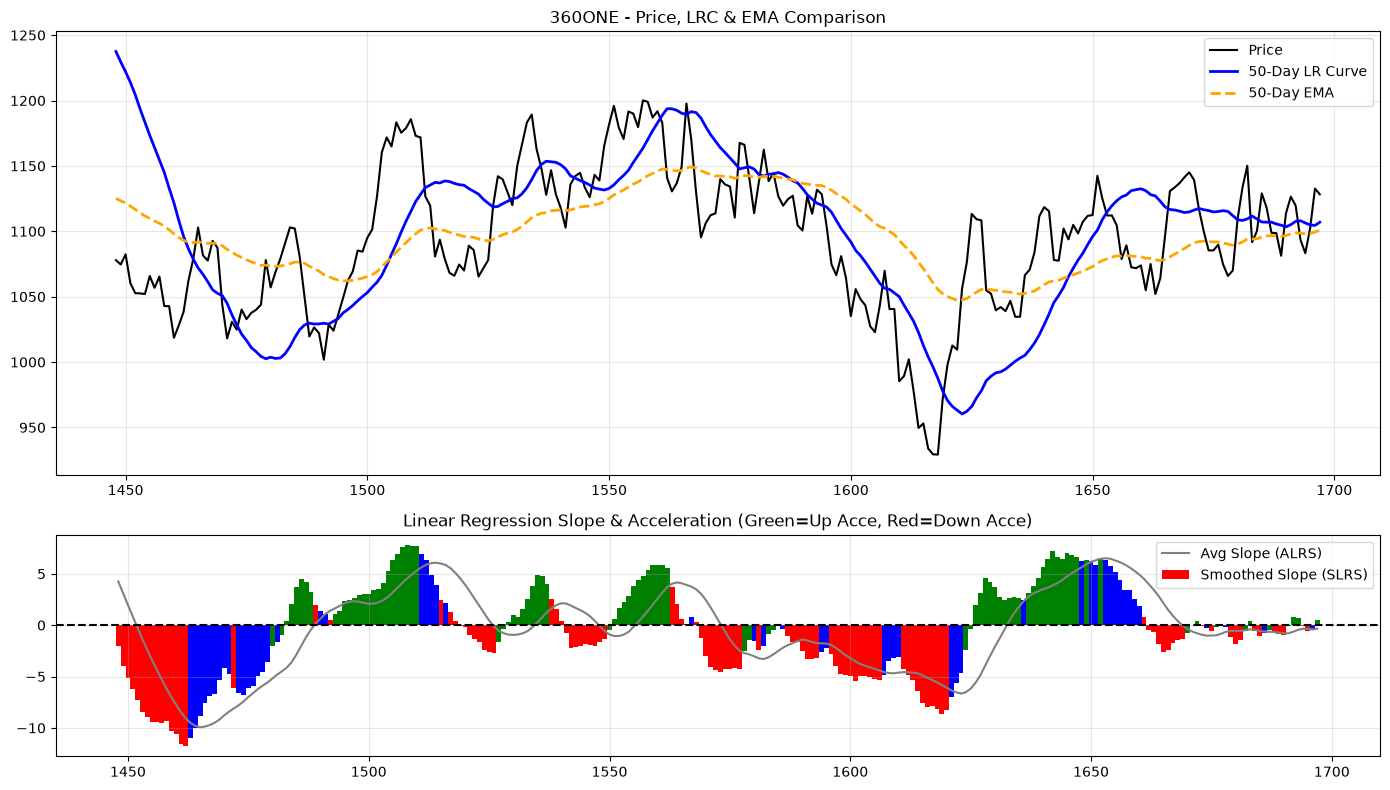

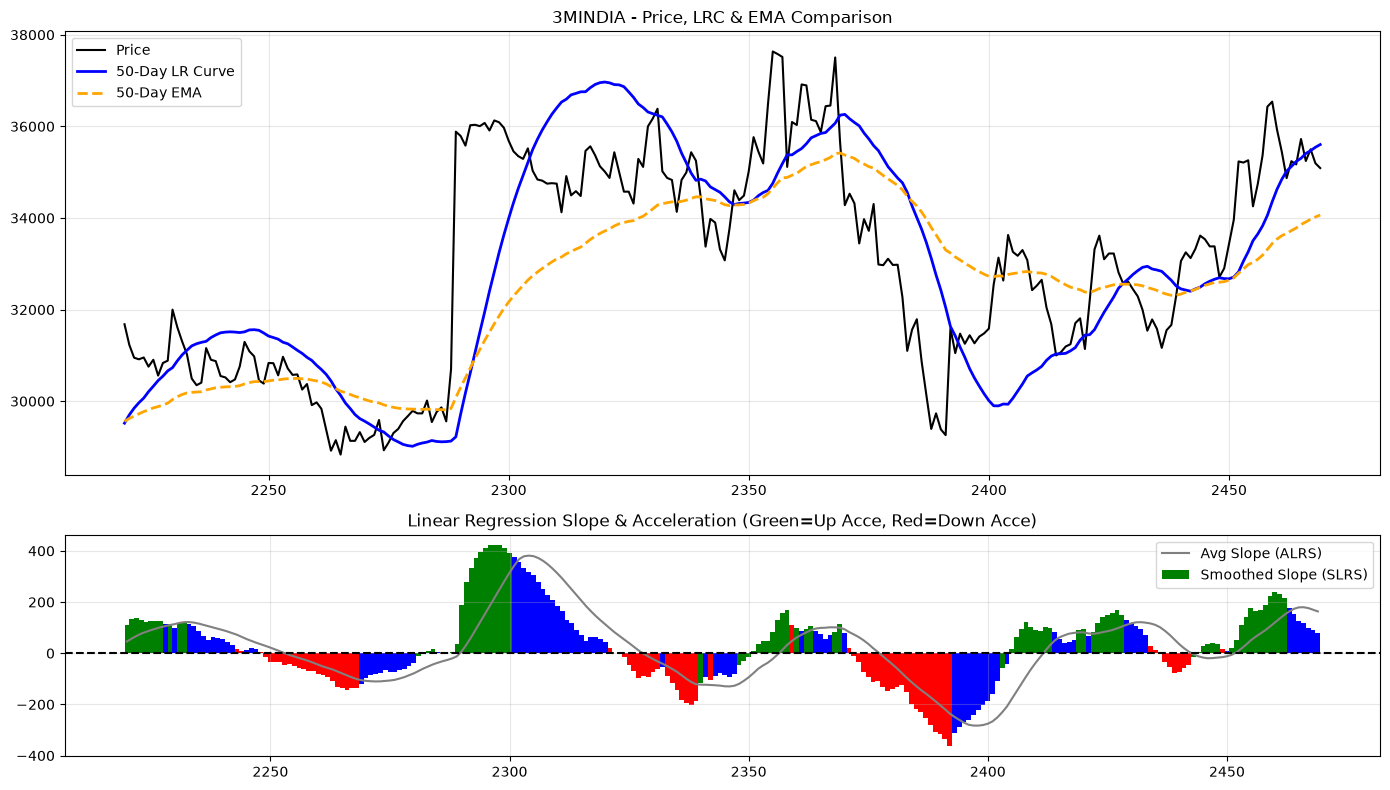

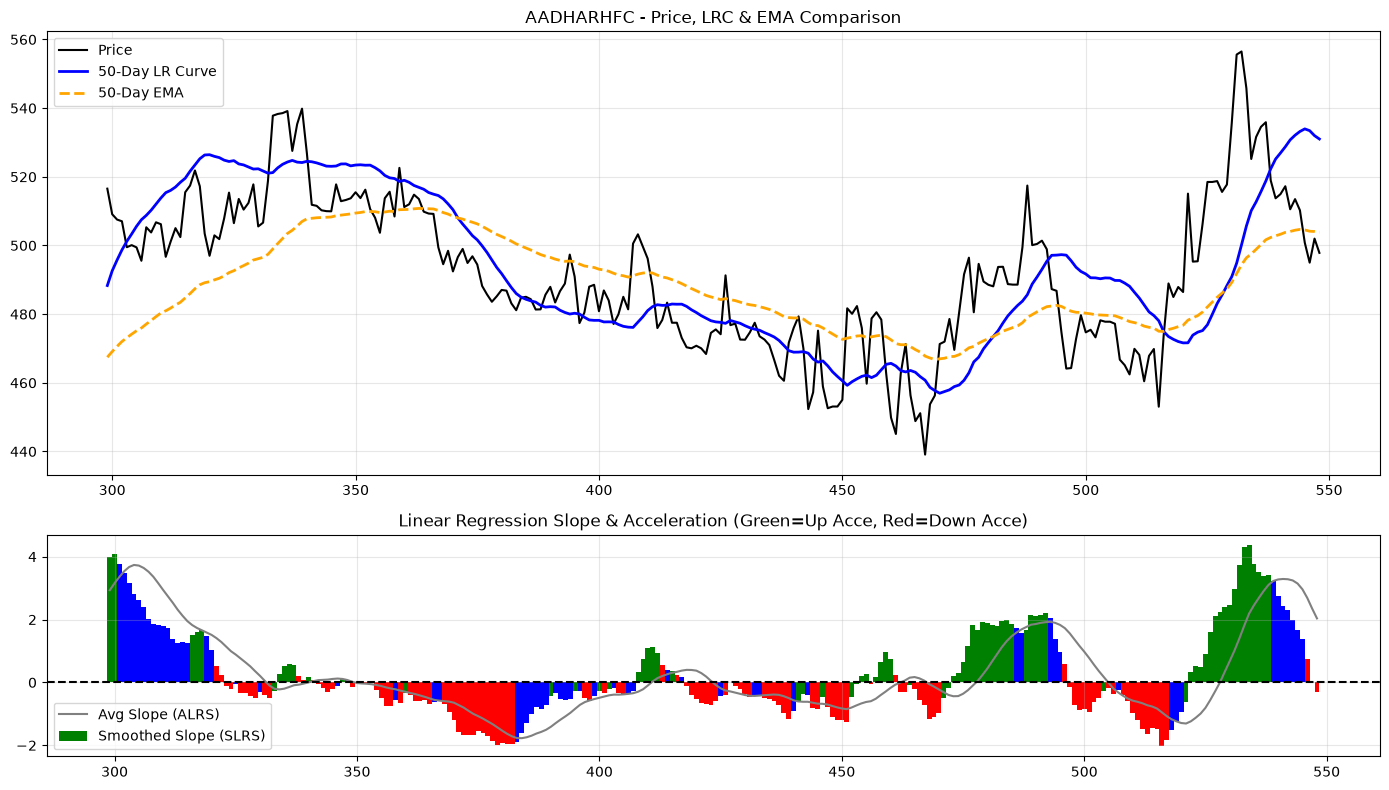

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import warnings

warnings.filterwarnings('ignore')

# Parameters from Pine Script
CLEN = 50
SLEN = 5
GLEN = 13
DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'

def rolling_linreg_endpoint(prices, window):
    # Fast rolling linear regression to get the endpoint (lrc)
    x = np.arange(window)
    x_mean = x.mean()
    x_var = x.var() * window # sum of squared deviations
    
    endpoints = np.full(len(prices), np.nan)
    
    for i in range(window, len(prices)):
        y = prices[i-window:i]
        y_mean = y.mean()
        cov = np.sum((x - x_mean) * (y - y_mean))
        slope = cov / x_var
        intercept = y_mean - slope * x_mean
        lrc = slope * (window - 1) + intercept
        endpoints[i] = lrc
        
    return endpoints

all_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
stocks_to_test = all_files[:3] # Pick the first 3 stocks

for file_path in stocks_to_test:
    stock_name = os.path.basename(file_path).split('.')[0]
    df = pd.read_csv(file_path)
    close_col = 'Close' if 'Close' in df.columns else 'close'
    
    # 1. Linear Regression Curve (Endpoint)
    df['LRC'] = rolling_linreg_endpoint(df[close_col].values, CLEN)
    
    # Add the Standard 50-day EMA for comparison
    df['EMA_50'] = df[close_col].ewm(span=CLEN, adjust=False).mean()
    
    # 2. Linear Regression Slope (Velocity)
    df['LRS'] = df['LRC'].diff()
    
    # 3. Smooth Linear Regression Slope
    df['SLRS'] = df['LRS'].ewm(span=SLEN, adjust=False).mean()
    
    # 4. Signal Linear Regression Slope (Average Slope)
    df['ALRS'] = df['SLRS'].rolling(window=GLEN).mean()
    
    # 5. Define Acceleration Colors
    df['U_Acce'] = (df['LRS'] > df['ALRS']) & (df['LRS'] > 0)
    df['D_Acce'] = (df['LRS'] < df['ALRS']) & (df['LRS'] < 0)
    
    df['Color'] = 'blue' # default / deceleration
    df.loc[df['U_Acce'], 'Color'] = 'green'
    df.loc[df['D_Acce'], 'Color'] = 'red'
    
    # Plotting
    plot_df = df.dropna().tail(250) # Plot last 250 days
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})
    
    ax1.plot(plot_df.index, plot_df[close_col], color='black', label='Price')
    ax1.plot(plot_df.index, plot_df['LRC'], color='blue', linestyle='-', linewidth=2, label='50-Day LR Curve')
    ax1.plot(plot_df.index, plot_df['EMA_50'], color='orange', linestyle='--', linewidth=2, label='50-Day EMA')
    ax1.set_title(f"{stock_name} - Price, LRC & EMA Comparison")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Bar chart for SLRS colored by acceleration state
    ax2.bar(plot_df.index, plot_df['SLRS'], color=plot_df['Color'], width=1.0, label='Smoothed Slope (SLRS)')
    ax2.plot(plot_df.index, plot_df['ALRS'], color='gray', label='Avg Slope (ALRS)')
    ax2.axhline(0, color='black', linestyle='--')
    ax2.set_title("Linear Regression Slope & Acceleration (Green=Up Acce, Red=Down Acce)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
